In [ ]:
pip install torch

In [ ]:
import torch
from torch import nn


In [ ]:
!pip install -q kaggle

In [ ]:
pip install kagglehub

In [ ]:
import os

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv(r"C:\Users\akhil\Documents\Dissertation work\data\fitzpatrick17k.csv")
print(df.shape[0])

In [ ]:
print(df['fitzpatrick_scale'].value_counts().sort_index())
print("total no of images in the dataset:",df.shape[0])

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
diseases = df['label'].unique()
print(diseases)
perdisease_counts = df['three_partition_label'].value_counts()
print(perdisease_counts)

In [ ]:
df=df[['md5hash','label','three_partition_label', 'fitzpatrick_scale','fitzpatrick_centaur']]

In [ ]:
df = df[df['fitzpatrick_scale'] > 0]

In [ ]:
singlecount=pd.crosstab(df['three_partition_label'], df['fitzpatrick_scale'])
print(singlecount)

In [ ]:
bar=singlecount.plot.bar(stacked=True) 
plt.title('Distribution of Fitzpatrick scores by different diseases')
plt.xlabel('disease Partition')
plt.ylabel('count')
plt.show()

In [ ]:
df.to_csv("data/new.csv", index=False)

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
df1 = pd.read_csv("data/new.csv")



traindata, t = train_test_split(df1,test_size=0.20, random_state=42,stratify=df1[['three_partition_label', 'fitzpatrick_scale']])

valdata, testdata = train_test_split(t,test_size=0.50,random_state=42,stratify=t[['three_partition_label', 'fitzpatrick_scale']])

traindata.to_csv("data/train.csv", index=False)
valdata.to_csv("data/val.csv", index=False)
testdata.to_csv("data/test.csv", index=False)

In [ ]:
traindf = pd.read_csv("data/train.csv")
print(traindf.shape)
print(traindf['fitzpatrick_scale'].value_counts())

In [ ]:
import os
import shutil
imagepath = "data/finalfitz17k"
splitpath = "data/splitimages"

trainpath = os.path.join(splitpath, "train")
valpath = os.path.join(splitpath, "val")
testpath = os.path.join(splitpath, "test")
for a, b in traindata.iterrows():
    traindest = os.path.join(trainpath, b['three_partition_label'], b['md5hash'] + ".jpg")
    source = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(traindest), exist_ok=True)
    shutil.copy(source, traindest)


for a, b in valdata.iterrows():
    valdest = os.path.join(valpath, b['three_partition_label'], b['md5hash'] + ".jpg")
    source = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(valdest), exist_ok=True)
    shutil.copy(source, valdest)



for a, b in testdata.iterrows():
    testdest = os.path.join(testpath, b['three_partition_label'], b['md5hash'] + ".jpg")
    source = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(testdest), exist_ok=True)
    shutil.copy(source, testdest)


fitz1= testdata[testdata['fitzpatrick_scale'] == 1]
fitz2 = testdata[testdata['fitzpatrick_scale'] == 2]
fitz3 = testdata[testdata['fitzpatrick_scale'] == 3]
fitz4 = testdata[testdata['fitzpatrick_scale'] == 4]
fitz5 = testdata[testdata['fitzpatrick_scale'] == 5]
fitz6 = testdata[testdata['fitzpatrick_scale'] == 6]
fitz1path = "data/splitimages/fitz1"
fitz2path = "data/splitimages/fitz2"    
fitz3path = "data/splitimages/fitz3"
fitz4path = "data/splitimages/fitz4"
fitz5path = "data/splitimages/fitz5"
fitz6path = "data/splitimages/fitz6"



for a, b in fitz1.iterrows():
    fitzdest = os.path.join(fitz1path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest), exist_ok=True)
    shutil.copy(source, fitzdest)


for a, b in fitz2.iterrows():
    fitzdest2 = os.path.join(fitz2path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source2 = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest2), exist_ok=True)
    shutil.copy(source2, fitzdest2)

    

for a, b in fitz3.iterrows():
    fitzdest3 = os.path.join(fitz3path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source3 = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest3), exist_ok=True)
    shutil.copy(source3, fitzdest3)

for a, b in fitz4.iterrows():
    fitzdest4 = os.path.join(fitz4path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source4 = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest4), exist_ok=True)
    shutil.copy(source4, fitzdest4)

for a, b in fitz5.iterrows():
    fitzdest5 = os.path.join(fitz5path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source5 = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest5), exist_ok=True)
    shutil.copy(source5, fitzdest5)


for a, b in fitz6.iterrows():
    fitzdest6 = os.path.join(fitz6path, b['three_partition_label'], b['md5hash'] + ".jpg")
    source6 = os.path.join(imagepath, b['md5hash'] +".jpg")
    os.makedirs(os.path.dirname(fitzdest6), exist_ok=True)
    shutil.copy(source6, fitzdest6)


In [ ]:
pip install torchvision

In [ ]:
from PIL import Image
import numpy as np
meanone, meantwo, meanthree = (0, 0, 0)
stdone, stdtwo, stdthree = (0, 0, 0)
num = 0
for a, b in traindata.iterrows():
 source = os.path.join(imagepath, b['md5hash'] + ".jpg")    
 arr = np.array(Image.open(source).convert('RGB')) 
    
 meanone = meanone + arr[:, :, 0].mean()
 meantwo = meantwo + arr[:, :, 1].mean()
 meanthree = meanthree + arr[:, :, 2].mean()
    
 stdone = stdone + arr[:, :, 0].std()
 stdtwo = stdtwo + arr[:, :, 1].std()
 stdthree = stdthree + arr[:, :, 2].std()
 num = num + 1

meanone = (meanone / num) /255
meantwo = (meantwo / num) /255
meanthree = (meanthree / num)/255

stdone = (stdone / num) /255
stdtwo = (stdtwo / num) /255
stdthree = (stdthree / num)/255

print(" Means:", meanone, meantwo, meanthree)
print(" Stds:", stdone, stdtwo, stdthree)

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn


In [ ]:
transformsone = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.6185, 0.4780, 0.4239], std=[0.1857, 0.1686, 0.1678])
])

transformstwo = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.6185, 0.4780, 0.4239], std=[0.1857, 0.1686, 0.1678])
])


In [ ]:
import os
from torch.utils.data import DataLoader

traindataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\train", transform=transformsone)
valdataset   = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\val", transform=transformstwo)
testdataset  = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\test", transform=transformstwo)

fitz1dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz1", transform=transformstwo)
fitz2dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz2", transform=transformstwo)
fitz3dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz3", transform=transformstwo)
fitz4dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz4", transform=transformstwo)
fitz5dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz5", transform=transformstwo)
fitz6dataset = datasets.ImageFolder(root=r"C:\Users\akhil\Documents\Dissertation work\data\splitimages\fitz6", transform=transformstwo)

trainn = DataLoader(traindataset, shuffle=True, batch_size=64)
vall   = DataLoader(valdataset, shuffle=False, batch_size=64)
testt  = DataLoader(testdataset, shuffle=False, batch_size=64)

fitz1data = DataLoader(fitz1dataset, shuffle=False, batch_size=64)
fitz2data = DataLoader(fitz2dataset, shuffle=False, batch_size=64)
fitz3data = DataLoader(fitz3dataset, shuffle=False, batch_size=64)
fitz4data = DataLoader(fitz4dataset, shuffle=False, batch_size=64)
fitz5data = DataLoader(fitz5dataset, shuffle=False, batch_size=64)
fitz6data = DataLoader(fitz6dataset, shuffle=False, batch_size=64)

In [ ]:
import pandas as pd
traindata = pd.read_csv(r"C:\Users\akhil\Documents\Dissertation work\data\train.csv")
print("distrubution of fitz scores across diseases")
print(pd.crosstab(traindata['fitzpatrick_scale'], traindata['three_partition_label']))

three_partition_label  benign  malignant  non-neoplastic
fitzpatrick_scale                                       
1                         355        362            1640
2                         537        594            2716
3                         380        365            1901
4                         294        241            1690
5                         127        118             981
6                          35         49             424


In [7]:
import torch
if torch.cuda.is_available():
    computation = "cuda"
else:
    computation = "cpu"

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, g=0, a=None, size_average=True):
        super(FocalLoss, self).__init__()
        self.g = g
        self.a = a
        if isinstance(self.a, (float, int)): 
            self.alpha = torch.Tensor([self.a, 1 - self.a])
        if isinstance(self.a, list): 
            self.alpha = torch.Tensor(self.a)
        self.size_average = size_average

    def forward(self, input, target):
        if input.dim() > 2:
            input = input.view(input.size(0), input.size(1), -1)  
            input = input.transpose(1, 2)                         
            input = input.contiguous().view(-1, input.size(2))    
        target = target.view(-1, 1)

        logpt = F.log_softmax(input, dim=1)
        logpt = logpt.gather(1, target)
        logpt = logpt.view(-1)
        pt = logpt.exp()

        if self.alpha is not None:
            if self.alpha.type() != input.data.type():
                self.alpha = self.alpha.type_as(input.data)
            at = self.alpha.gather(0, target.data.view(-1))
            logpt = logpt * at

        loss = -1 * (1 - pt) ** self.g * logpt
        if self.size_average: 
            return loss.mean()
        else: 
            return loss.sum()

In [41]:
import random,numpy as np
seed = 5099
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_auc_score, balanced_accuracy_score
def evaluatefitz(model, dataloader, device):
    corr = []
    predictions = []
    probabilities = []
    epochs = 1

    for epoch in range(epochs):
        model.eval()
        ls = 0

        accur, total = 0, 0
        with torch.inference_mode():
            for batches, (x, y) in enumerate(dataloader):
                x = x.to(device)
                y = y.to(device)
                forward = model(x)
                probabilities = torch.nn.functional.softmax(forward, dim=1)
                loss = criterion(forward, y)  
                ls += loss.item()
                forwardclass = forward.argmax(dim=1)

                corr.extend(y.cpu().numpy())
                probabilities.extend(probabilities.cpu().numpy())
                predictions.extend(forwardclass.cpu().numpy())
                accur =accur+ (forwardclass == y).sum().item()
                total = total+ len(y)

    avgacc = accur / total
    avgloss = ls / len(dataloader)

    precision, recall, f1, f2 = precision_recall_fscore_support(corr, predictions, average=None)
    auc = roc_auc_score(np.array(corr), np.array(probabilities), multi_class='ovr', average='macro')
    fnr = 1 - recall
    balancedaccur = balanced_accuracy_score(corr, predictions)
    confusionmatrix = confusion_matrix(corr, predictions)
    print(f"The  accuracy for the dataset is : {avgacc}")
    print(f"The precision for the dataset is {precision}")
    print(f"The AUC score for the dataset is {auc}")
    print(f"The recall for the dataset is  {recall}")
    print(f"The Loss: for the dataaset is {avgloss}")
    print(f"The False Negative Rate for the dataset is {fnr}")
    print(f"The confusion matrix for the dataset is:{confusionmatrix}")
    print(f"The balanced accuracy for the dataset is: {balancedaccur}")




In [ ]:
import torchvision.models as models
import torch.optim as optim
rate=0.001
nepochs = 50
device = torch.device(computation)
classes = 3
weight=[2.4709, 2.464, 0.4566]

resnetscore = models.resnet50(pretrained=True)
resnetscore.fc = torch.nn.Linear(resnetscore.fc.in_features, classes)
resnetscore = resnetscore.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnetscore.parameters(), lr=rate)


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
nepochs=50
lossvalues = []
lossvalues2 = []
lamb = 0.01 
pat= 3
limepoch = 0
maxvalloss = 1000

##training
for epoch in range(nepochs):
    resnetscore.train()
    total, l, totalaccur = 0, 0, 0
    
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = resnetscore(a)
            loss = criterion(forward, b)
        loss.backward()
        optimizer.step()

        l += loss.item()

        forwardclass = forward.argmax(dim=1)
        totalaccur =totalaccur + (forwardclass == b).sum().item()

    avgaccur = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgaccur}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    ##val
    resnetscore.eval()
    l2 = 0
    accur2 = 0
    
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            
            forward1 = resnetscore(a1)
            loss2 = criterion(forward1, b1)
            l2 += loss2.item()

            forwardclass1 = forward1.argmax(dim=1)
            accur2 = accur2 + (forwardclass1 == b1).sum().item() / len(forward1)

        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        
        print(f"The validation acc is: {avgvalacc}")
        print("-----")
        print(f"The validation loss is: {avgvalloss}")

    if (avgvalloss < maxvalloss):
        maxvalloss = avgvalloss
        limepoch= 0
        save = r"c:\Users\akhil\Downloads\resnet_spectral.pth"
        torch.save(resnetscore.state_dict(), save)
    else:
        limepoch =limepoch + 1
        print("val loss stagnant")
        
        if (limepoch>= pat):
            print(f"final stop at epoch {epoch+1}")
            break

Epoch number 1
//////
The training acc is: 75.41572331954094
/////
The training loss is: 0.6618822566905425
The validation acc is: 77.82451923076923
/////
The validation loss is: 0.5826155589177058
Epoch number 2
//////
The training acc is: 78.88984307908503
/////
The training loss is: 0.5685553844295331
The validation acc is: 79.32692307692307
/////
The validation loss is: 0.5556358924278846
Epoch number 3
//////
The training acc is: 80.14677180107736
/////
The training loss is: 0.5238035244135121
The validation acc is: 80.76923076923077
/////
The validation loss is: 0.5374195071367117
Epoch number 4
//////
The training acc is: 81.59887579045983
/////
The training loss is: 0.4968788659394677
The validation acc is: 81.43028846153845
/////
The validation loss is: 0.5168270881359394
Epoch number 5
//////
The training acc is: 82.06729643219612
/////
The training loss is: 0.4756334965205311
The validation acc is: 81.73076923076923
/////
The validation loss is: 0.501251968053671
Epoch numbe

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

Extracting Test Set Features: 100%|██████████| 26/26 [00:53<00:00,  2.04s/it]


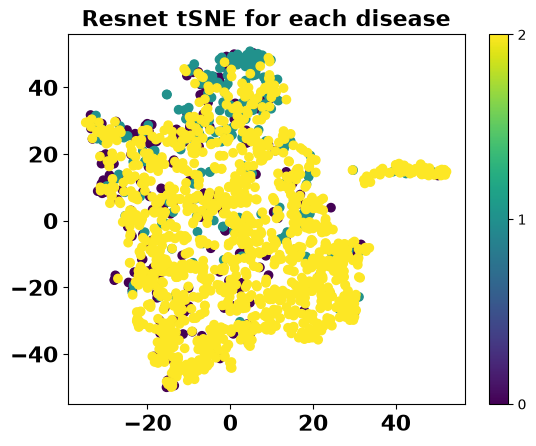

In [ ]:
from sklearn.manifold import TSNE
from tqdm import tqdm
resnetscore.eval()
res = resnetscore.fc                    
resnetscore.fc = torch.nn.Identity()

out = np.empty((0, 2048))      
label = []               

for batch in testt:
    images = batch[0].to(device)
    diseases = batch[1]       
    with torch.no_grad():
        output = resnetscore(images)     
        
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + diseases.tolist() 
resnetscore.fc = res                             

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

tx = tsnevis[:, 0]
ty = tsnevis[:, 1]

scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[0, 1, 2])
plt.title("Resnet tSNE for each disease", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')
plt.show()

In [ ]:
resnetscore.eval()
res=resnetscore.fc
resnetscore.fc = torch.nn.Identity()
out = np.empty((0, 2048))
label = []

for batch in fitz1data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [1] * len(images)

for batch in fitz2data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [2] * len(images)

for batch in fitz3data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [3] * len(images)

for batch in fitz4data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [4] * len(images)

for batch in fitz5data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [5] * len(images)

for batch in fitz6data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = resnetscore(images)
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [6] * len(images)

resnetscore.fc = res
feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure()
tx=tsnevis[:, 0]
ty=tsnevis[:, 1]
scatter = plt.scatter(tx, ty,color=label)
plt.colorbar(scatter, ticks=[1, 2, 3, 4, 5, 6])
plt.title("tSNE")
plt.show()


TypeError: 'module' object is not callable

In [ ]:
evaluatefitz(resnetscore, testt, device)

The  accuracy for the dataset is : 0.8183520599250936
The precision for the dataset is [0.57055215 0.80952381 0.84996192]
The AUC score for the dataset is 0.873807053719951
The recall for the dataset is  [0.43255814 0.47222222 0.9530316 ]
The Loss: for the dataaset is 0.4726007024829204
The False Negative Rate for the dataset is [0.56744186 0.52777778 0.0469684 ]
The confusion matrix for the dataset is:[[  93    7  115]
 [  32  102   82]
 [  38   17 1116]]
The balanced accuracy for the dataset is: 0.6192706528942701


In [ ]:
print("Evaluating Fitzpatrick Type 1")
evaluatefitz(resnetscore, fitz1data, device)

Evaluating Fitzpatrick Type 1
The  accuracy for the dataset is : 0.8067796610169492
The precision for the dataset is [0.65714286 0.71428571 0.84051724]
The AUC score for the dataset is 0.8621359862856385
The recall for the dataset is  [0.52272727 0.43478261 0.95121951]
The Loss: for the dataaset is 0.5372046887874603
The False Negative Rate for the dataset is [0.47727273 0.56521739 0.04878049]
The confusion matrix for the dataset is:[[ 23   2  19]
 [  8  20  18]
 [  4   6 195]]
The balanced accuracy for the dataset is: 0.6362431312060156


In [ ]:
print("Evaluating Fitzpatrick Type 2")
evaluatefitz(resnetscore, fitz2data, device)

Evaluating Fitzpatrick Type 2
The  accuracy for the dataset is : 0.8004158004158004
The precision for the dataset is [0.5625     0.77777778 0.83247423]
The AUC score for the dataset is 0.8696625824151587
The recall for the dataset is  [0.40298507 0.47297297 0.95      ]
The Loss: for the dataaset is 0.5026728101074696
The False Negative Rate for the dataset is [0.59701493 0.52702703 0.05      ]
The confusion matrix for the dataset is:[[ 27   5  35]
 [  9  35  30]
 [ 12   5 323]]
The balanced accuracy for the dataset is: 0.6086526825332795


In [ ]:

print("Evaluating Fitzpatrick Type 3")
evaluatefitz(resnetscore, fitz3data, device)

Evaluating Fitzpatrick Type 3
The  accuracy for the dataset is : 0.8072289156626506
The precision for the dataset is [0.52777778 0.83870968 0.84150943]
The AUC score for the dataset is 0.867476311987741
The recall for the dataset is  [0.39583333 0.56521739 0.93697479]
The Loss: for the dataaset is 0.44902392600973445
The False Negative Rate for the dataset is [0.60416667 0.43478261 0.06302521]
The confusion matrix for the dataset is:[[ 19   0  29]
 [  7  26  13]
 [ 10   5 223]]
The balanced accuracy for the dataset is: 0.6326751715178826


In [ ]:

print("Evaluating Fitzpatrick Type 4")
evaluatefitz(resnetscore, fitz4data, device)

Evaluating Fitzpatrick Type 4
The  accuracy for the dataset is : 0.8525179856115108
The precision for the dataset is [0.58064516 1.         0.87982833]
The AUC score for the dataset is 0.9127763041432604
The recall for the dataset is  [0.5        0.46666667 0.96698113]
The Loss: for the dataaset is 0.35138298869132994
The False Negative Rate for the dataset is [0.5        0.53333333 0.03301887]
The confusion matrix for the dataset is:[[ 18   0  18]
 [  6  14  10]
 [  7   0 205]]
The balanced accuracy for the dataset is: 0.6445492662473794


In [ ]:

print("Evaluating Fitzpatrick Type 5")
evaluatefitz(resnetscore, fitz5data, device)

Evaluating Fitzpatrick Type 5
The  accuracy for the dataset is : 0.8169934640522876
The precision for the dataset is [0.33333333 0.8        0.84892086]
The AUC score for the dataset is 0.8322338004364432
The recall for the dataset is  [0.1875     0.28571429 0.95934959]
The Loss: for the dataaset is 0.39645593116680783
The False Negative Rate for the dataset is [0.8125     0.71428571 0.04065041]
The confusion matrix for the dataset is:[[  3   0  13]
 [  2   4   8]
 [  4   1 118]]
The balanced accuracy for the dataset is: 0.47752129307007357


In [ ]:

print("Evaluating Fitzpatrick Type 6")
evaluatefitz(resnetscore, fitz6data, device)

Evaluating Fitzpatrick Type 6
The  accuracy for the dataset is : 0.9206349206349206
The precision for the dataset is [0.75       1.         0.92857143]
The AUC score for the dataset is 0.9003945077489588
The recall for the dataset is  [0.75       0.5        0.98113208]
The Loss: for the dataaset is 0.33144044876098633
The False Negative Rate for the dataset is [0.25       0.5        0.01886792]
The confusion matrix for the dataset is:[[ 3  0  1]
 [ 0  3  3]
 [ 1  0 52]]
The balanced accuracy for the dataset is: 0.7437106918238993


In [ ]:
densenetscore = models.densenet121(pretrained=True)
densenetscore.classifier = torch.nn.Linear(densenetscore.classifier.in_features, classes)
densenetscore = densenetscore.to(device)

c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

nepochs = 40
optimizer = optim.Adam(densenetscore.parameters(), lr=rate)
lossvalues = []
lossvalues2 = []

pat = 3
limepochs=0
maxvalloss = 1000

for epoch in range(nepochs):
    ##training
    densenetscore.train()
    total, l, totalaccur = 0, 0, 0
    
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = densenetscore(a)
            loss=criterion(forward, b)
        loss.backward()
        optimizer.step()

        l += loss.item()

        forwardclass = forward.argmax(dim=1)
        totalaccur =totalaccur+ (forwardclass == b).sum().item()

    avgaccur = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    
    print(f"The epoch number is {epoch + 1}")
    print("------")
    print(f"The training acc is: {avgaccur}")
    print("------")
    print(f"The training loss is: {avgloss}")

    ##validation
    densenetscore.eval()
    l2 = 0
    accur2 = 0
    
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            
            forward1 = densenetscore(a1)
            loss2 = criterion(forward1, b1)
            l2 += loss2.item()

            forwardclass1 = forward1.argmax(dim=1)
            accur2 += (forwardclass1 == b1).sum().item() / len(forward1)

        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        
        print(f"The validation acc is: {avgvalacc}")
        print("------")
        print(f"The validation loss is: {avgvalloss}")

    if (avgvalloss < maxvalloss):
        maxvalloss = avgvalloss
        limepochs = 0
        save_path = r"c:\Users\akhil\Downloads\densenet121-runtwo.pth"
        torch.save(densenetscore.state_dict(), save_path)
    else:
        limepoch += 1
        print("val loss stagnant")
       
        if (limepoch >= pat):
            print(f"final stop at epoch {epoch+1}")
            break

Epoch number 1
//////
The training acc is: 73.76063705207277
/////
The training loss is: 0.6828448096318032
The validation acc is: 78.54567307692307
/////
The validation loss is: 0.580752629500169
Epoch number 2
//////
The training acc is: 80.56835037864002
/////
The training loss is: 0.5264972870919242
The validation acc is: 79.8076923076923
/////
The validation loss is: 0.5480814025952265
Epoch number 3
//////
The training acc is: 82.43422593488953
/////
The training loss is: 0.4775106791240066
The validation acc is: 82.39182692307693
/////
The validation loss is: 0.47978355563603914
Epoch number 4
//////
The training acc is: 83.36326020766649
/////
The training loss is: 0.44220233779048446
The validation acc is: 82.99278846153845
/////
The validation loss is: 0.4792680854980762
Epoch number 5
//////
The training acc is: 85.11983761417753
/////
The training loss is: 0.4087755929178266
The validation acc is: 82.9326923076923
/////
The validation loss is: 0.484397312769523
Validation l

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

Extracting Test Set Features: 100%|██████████| 26/26 [03:15<00:00,  7.51s/it]


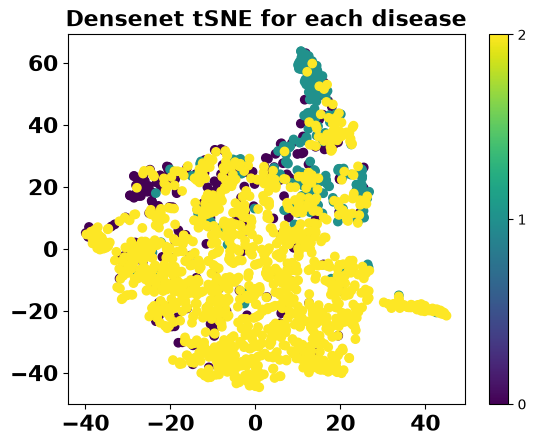

In [ ]:
densenetscore.eval()
den = densenetscore.classifier         
densenetscore.classifier = torch.nn.Identity()

out = np.empty((0, 1024))     
label = []               

for batch in testt:
    images = batch[0].to(device)
    diseases = batch[1]       
    with torch.no_grad():
        output = densenetscore(images)   
        
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + diseases.tolist() 
densenetscore.classifier = den                       

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

tx = tsnevis[:, 0]
ty = tsnevis[:, 1]

scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[0, 1, 2])
plt.title("Densenet tSNE for each disease", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')
plt.show()

In [ ]:
evaluatefitz(densenetscore, testt, device)

The  accuracy for the dataset is : 0.8352059925093633
The precision for the dataset is [0.6516129  0.78343949 0.86356589]
The AUC score for the dataset is 0.887164354712874
The recall for the dataset is  [0.46976744 0.56944444 0.95132365]
The Loss: for the dataaset is 0.4417863918038515
The False Negative Rate for the dataset is [0.53023256 0.43055556 0.04867635]
The confusion matrix for the dataset is:[[ 101   14  100]
 [  17  123   76]
 [  37   20 1114]]
The balanced accuracy for the dataset is: 0.6635118471002133


In [ ]:
densenetscore.eval()
den = densenetscore.classifier             
densenetscore.classifier = torch.nn.Identity()

out = np.empty((0, 1024))   
label = []

for batch in fitz1data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [1] * len(images)

for batch in fitz2data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [2] * len(images)

for batch in fitz3data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [3] * len(images)

for batch in fitz4data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [4] * len(images)

for batch in fitz5data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)      
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [5] * len(images)

for batch in fitz6data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = densenetscore(images)      
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [6] * len(images)

densenetscore.classifier = den            

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure(figsize=(10, 8))
tx = tsnevis[:, 0]
ty = tsnevis[:, 1]
scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[1, 2, 3, 4, 5, 6])
plt.title("DensenettSNE")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
epochlist = list(range(1, nepochs + 1))
print("Epoch List:", epochlist)
plt.plot(epochlist, lossvalues, label='The training loss')
plt.plot(epochlist, lossvalues2, label='The validation loss')

plt.xlabel("The number of epochs")
plt.ylabel("The loss")
plt.title("Densenet121 learning curve")

plt.legend()
plt.show()

In [ ]:
##fitzpatrick evaluation for densenet
##fitzpatrick 1

print("Evaluating Fitzpatrick 1 for Densenet121")
evaluatefitz(densenetscore, fitz1data, device)

Evaluating Fitzpatrick 1 for Densenet121
The  accuracy for the dataset is : 0.7932203389830509
The precision for the dataset is [0.53846154 0.78571429 0.8377193 ]
The AUC score for the dataset is 0.8810342843283623
The recall for the dataset is  [0.47727273 0.47826087 0.93170732]
The Loss: for the dataaset is 0.49223409295082093
The False Negative Rate for the dataset is [0.52272727 0.52173913 0.06829268]
The confusion matrix for the dataset is:[[ 21   3  20]
 [  7  22  17]
 [ 11   3 191]]
The balanced accuracy for the dataset is: 0.6290803046370385


In [ ]:
print("Evaluating Fitzpatrick 2 for Densenet121")
evaluatefitz(densenetscore, fitz2data, device)

Evaluating Fitzpatrick 2 for Densenet121
The  accuracy for the dataset is : 0.8253638253638254
The precision for the dataset is [0.61702128 0.84313725 0.84856397]
The AUC score for the dataset is 0.8874165815082226
The recall for the dataset is  [0.43283582 0.58108108 0.95588235]
The Loss: for the dataaset is 0.45687945932149887
The False Negative Rate for the dataset is [0.56716418 0.41891892 0.04411765]
The confusion matrix for the dataset is:[[ 29   5  33]
 [  6  43  25]
 [ 12   3 325]]
The balanced accuracy for the dataset is: 0.65659975163926


In [ ]:
print("Evaluating Fitzpatrick 3 for Densenet121")
evaluatefitz(densenetscore, fitz3data, device)

Evaluating Fitzpatrick 3 for Densenet121
The  accuracy for the dataset is : 0.8403614457831325
The precision for the dataset is [0.75       0.73170732 0.86872587]
The AUC score for the dataset is 0.8862354725377708
The recall for the dataset is  [0.5        0.65217391 0.94537815]
The Loss: for the dataaset is 0.41050844887892407
The False Negative Rate for the dataset is [0.5        0.34782609 0.05462185]
The confusion matrix for the dataset is:[[ 24   4  20]
 [  2  30  14]
 [  6   7 225]]
The balanced accuracy for the dataset is: 0.6991840214346609


In [ ]:
print("Evaluating Fitzpatrick 4 for Densenet121")
evaluatefitz(densenetscore, fitz4data, device)

Evaluating Fitzpatrick 4 for Densenet121
The  accuracy for the dataset is : 0.8812949640287769
The precision for the dataset is [0.875      0.75       0.89565217]
The AUC score for the dataset is 0.9082371698318138
The recall for the dataset is  [0.58333333 0.6        0.97169811]
The Loss: for the dataaset is 0.3344067558646202
The False Negative Rate for the dataset is [0.41666667 0.4        0.02830189]
The confusion matrix for the dataset is:[[ 21   2  13]
 [  1  18  11]
 [  2   4 206]]
The balanced accuracy for the dataset is: 0.7183438155136268


In [ ]:
print("Evaluating Fitzpatrick 5 for Densenet121")
evaluatefitz(densenetscore, fitz5data, device)

Evaluating Fitzpatrick 5 for Densenet121
The  accuracy for the dataset is : 0.8562091503267973
The precision for the dataset is [0.54545455 0.8        0.88636364]
The AUC score for the dataset is 0.8843126439868985
The recall for the dataset is  [0.375      0.57142857 0.95121951]
The Loss: for the dataaset is 0.34697338938713074
The False Negative Rate for the dataset is [0.625      0.42857143 0.04878049]
The confusion matrix for the dataset is:[[  6   0  10]
 [  1   8   5]
 [  4   2 117]]
The balanced accuracy for the dataset is: 0.6325493612078977


In [ ]:
print("Evaluating Fitzpatrick 6 for Densenet121")
evaluatefitz(densenetscore, fitz6data, device)

Evaluating Fitzpatrick 6 for Densenet121
The  accuracy for the dataset is : 0.8253968253968254
The precision for the dataset is [0.         0.66666667 0.86206897]
The AUC score for the dataset is 0.7768874937583806
The recall for the dataset is  [0.         0.33333333 0.94339623]
The Loss: for the dataaset is 0.461337149143219
The False Negative Rate for the dataset is [1.         0.66666667 0.05660377]
The confusion matrix for the dataset is:[[ 0  0  4]
 [ 0  2  4]
 [ 2  1 50]]
The balanced accuracy for the dataset is: 0.42557651991614254


In [ ]:
import torchvision.models as models
import torch.optim as optim
rate=0.001
nepochs = 40
device = torch.device(computation)
classes = 3

criterion = nn.CrossEntropyLoss()

vitscore = models.vit_b_16(pretrained=True)
vitscore.heads.head = torch.nn.Linear(vitscore.heads.head.in_features, classes)
vitscore = vitscore.to(device)
optimizer = optim.Adam(vitscore.parameters(), lr=rate)


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch.nn.functional as F

optimizer = optim.Adam(vitscore.parameters(), lr=rate)
lossvalues = []
lossvalues2 = []



pat = 3
limepoch = 0
maxvalloss = 1000 
scal = torch.amp.GradScaler()
for epoch in range(nepochs):
    ##training
    vitscore.train()
    total, l, totalaccur = 0, 0, 0
    
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = vitscore(a)
            loss = criterion(forward, b)
        loss.backward()
        optimizer.step()

        l =l + loss.item()

        forwardclass = forward.argmax(dim=1)
        totalaccur =totalaccur + (forwardclass == b).sum().item()

    avgaccur = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    
    print(f"The epoch number is {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgaccur}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    ###validation
    vitscore.eval()
    l2 = 0
    accur2 = 0
    
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            
            forward1 = vitscore(a1)
            loss2 = criterion(forward1, b1)
            l2 =l2+ loss2.item()

            forwardclass1 = forward1.argmax(dim=1)
            accur2 =accur2+ (forwardclass1 == b1).sum().item() / len(forward1)

        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        
        print(f"The validation acc is: {avgvalacc}")
        print("-----")
        print(f"The validation loss is: {avgvalloss}")

    if avgvalloss < maxvalloss:
        maxvalloss = avgvalloss
        limepoch = 0
        save = r"c:\Users\akhil\Downloads\vit_b_16_run 2.pth"
        torch.save(vitscore.state_dict(), save)
    else:
        limepoch =limepoch+ 1
        print("val loss stagnant")        
        if limepoch >= pat:
            print(f"final stop at epoch {epoch+1}")
            break

Epoch number 1
//////
The training acc is: 72.56616441564525
/////
The training loss is: 0.8075222785200052
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.7520045030575532
Epoch number 2
//////
The training acc is: 73.01116402529472
/////
The training loss is: 0.7824506743333826
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.7765537586349708
Validation loss did not improve. Consecutive epochs without improvement: 1/3
Epoch number 3
//////
The training acc is: 72.9799359825123
/////
The training loss is: 0.7793926641122618
The validation acc is: 73.91826923076923
/////
The validation loss is: 0.7586594407375042
Validation loss did not improve. Consecutive epochs without improvement: 2/3
Epoch number 4
//////
The training acc is: 73.01897103599032
/////
The training loss is: 0.7749945628109263
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.7590347878061808
Validation loss did not improve. Consecutive epochs wit

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

Extracting Test Set Features: 100%|██████████| 26/26 [01:08<00:00,  2.62s/it]


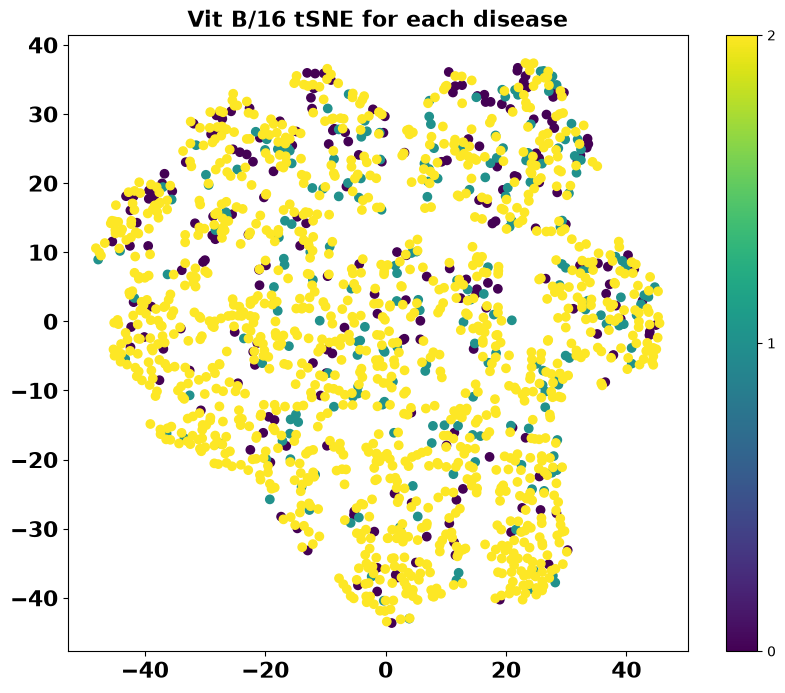

In [ ]:
vitscore.eval()
vitt = vitscore.heads.head              
vitscore.heads.head = torch.nn.Identity()

out = np.empty((0, 768))     
label = []               

for batch in tqdm(testt, desc='Extracting Test Set Features'):
    images = batch[0].to(device)
    diseases = batch[1]      
    with torch.no_grad():
        output = vitscore(images)     
        
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + diseases.tolist() 
vitscore.heads.head = vitt                         

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure(figsize=(10, 8))
tx = tsnevis[:, 0]
ty = tsnevis[:, 1]

scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[0, 1, 2])
plt.xticks(fontsize=16,fontweight='bold')
plt.yticks(fontsize=16,fontweight='bold')
plt.title("Vit B/16 tSNE for each disease", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
vitscore.eval()
vitt = vitscore.heads.head             
vitscore.heads.head = torch.nn.Identity()

out = np.empty((0, 768))   
label = []

for batch in fitz1data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [1] * len(images)

for batch in fitz2data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [2] * len(images)

for batch in fitz3data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [3] * len(images)

for batch in fitz4data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [4] * len(images)

for batch in tqdm(fitz5data, desc='Extracting Fitzpatrick Type 5'):
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [5] * len(images)

for batch in fitz6data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = vitscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [6] * len(images)

vitscore.heads.head = vitt             

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure(figsize=(10, 8))
tx = tsnevis[:, 0]
ty = tsnevis[:, 1]
scatter = plt.scatter(tx, ty, color=label) 
plt.colorbar(scatter, ticks=[1, 2, 3, 4, 5, 6])
plt.title("Vit B/16 t-SNE")    
plt.show()

In [ ]:
evaluatefitz(vitscore, testt, device)

The  accuracy for the dataset is : 0.7309612983770287
The precision for the dataset is [0.        0.        0.7309613]
The AUC score for the dataset is 0.5215635726717457
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7576946266568624
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[   0    0  215]
 [   0    0  216]
 [   0    0 1171]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 1 for vit")
evaluatefitz(vitscore, fitz1data, device)   

Evaluating Fitzpatrick 1 for vit
The  accuracy for the dataset is : 0.6949152542372882
The precision for the dataset is [0.         0.         0.69491525]
The AUC score for the dataset is 0.5139569256949923
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.8012611210346222
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  44]
 [  0   0  46]
 [  0   0 205]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 2 for vit")
evaluatefitz(vitscore, fitz2data, device)

Evaluating Fitzpatrick 2 for vit
The  accuracy for the dataset is : 0.7068607068607069
The precision for the dataset is [0.         0.         0.70686071]
The AUC score for the dataset is 0.5182269004273685
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7894661966711283
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  67]
 [  0   0  74]
 [  0   0 340]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 3 for vit")
evaluatefitz(vitscore, fitz3data, device)

Evaluating Fitzpatrick 3 for vit
The  accuracy for the dataset is : 0.7168674698795181
The precision for the dataset is [0.         0.         0.71686747]
The AUC score for the dataset is 0.5242097912288979
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7298138389984766
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  48]
 [  0   0  46]
 [  0   0 238]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 4 for vit")
evaluatefitz(vitscore, fitz4data, device)

Evaluating Fitzpatrick 4 for vit
The  accuracy for the dataset is : 0.762589928057554
The precision for the dataset is [0.         0.         0.76258993]
The AUC score for the dataset is 0.5079461898909418
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.654092276096344
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  36]
 [  0   0  30]
 [  0   0 212]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 5 for vit")
evaluatefitz(vitscore, fitz5data, device)

Evaluating Fitzpatrick 5 for vit
The  accuracy for the dataset is : 0.803921568627451
The precision for the dataset is [0.         0.         0.80392157]
The AUC score for the dataset is 0.5426390615171334
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.5542579938968023
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  16]
 [  0   0  14]
 [  0   0 123]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 6 for vit")
evaluatefitz(vitscore, fitz6data, device)

Evaluating Fitzpatrick 6 for vit
The  accuracy for the dataset is : 0.8412698412698413
The precision for the dataset is [0.         0.         0.84126984]
The AUC score for the dataset is 0.5879861372152622
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.5555086731910706
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[ 0  0  4]
 [ 0  0  6]
 [ 0  0 53]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
import torch

rate=0.001
nepochs = 50
device = torch.device(computation)
classes = 3

criterion = nn.CrossEntropyLoss()


swinscore = models.swin_t(pretrained=True)

swinscore.head = torch.nn.Linear(swinscore.head.in_features, classes)
swinscore = swinscore.to(device)

optimizer = optim.Adam(swinscore.parameters(), lr=rate)
scal = torch.amp.GradScaler()

c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
optimizer = optim.Adam(swinscore.parameters(), lr=rate)
lossvalues = []
lossvalues2 = []

labda=0.01
pat = 3
limepoch = 0
maxvalloss = 1000
scal = torch.amp.GradScaler()

for epoch in range(nepochs):
    ##training
    
    swinscore.train()
    total, l, totalaccur = 0, 0, 0
    
    for batches, (a, b) in enumerate(trainn):
        a = a.to(device)
        b = b.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            forward = swinscore(a)
            loss=criterion(forward, b)
            
        scal.scale(loss).backward()
        scal.step(optimizer)
        scal.update()

        l =l + loss.item()

        forwardclass = forward.argmax(dim=1)
        totalaccur = totalaccur + (forwardclass == b).sum().item()

    avgaccur = totalaccur / len(traindataset) * 100
    avgloss = l / len(trainn)
    lossvalues.append(avgloss)
    
    print(f"Epoch number {epoch + 1}")
    print("-----")
    print(f"The training acc is: {avgaccur}")
    print("-----")
    print(f"The training loss is: {avgloss}")

    swinscore.eval()
    l2 = 0
    accur2 = 0
    
    with torch.no_grad():
        for batches, (a1, b1) in enumerate(vall):
            a1 = a1.to(device)
            b1 = b1.to(device)
            
            forward1 = swinscore(a1)
            loss2 = criterion(forward1, b1)
            l2 = l2 + loss2.item()

            forwardclass1 = forward1.argmax(dim=1)
            accur2 = accur2 + (forwardclass1 == b1).sum().item() / len(forward1)

        avgvalacc = accur2 / len(vall) * 100
        avgvalloss = l2 / len(vall)
        lossvalues2.append(avgvalloss)
        
        print(f"The validation acc is: {avgvalacc}")
        print("-----")
        print(f"The validation loss is: {avgvalloss}")

    if avgvalloss < maxvalloss:
        maxvalloss = avgvalloss
        limepoch = 0
        save = r"c:\Users\akhil\Downloads\swin_spectral.pth"
        torch.save(swinscore.state_dict(), save)
    else:
        limepoch += 1
        print("val loss stagnant")
        
        if limepoch >= pat:
            print(f"final stop at epoch {epoch+1}")

            break

Epoch number 1
//////
The training acc is: 72.4802872979936
/////
The training loss is: 0.7917541146871463
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.760879826087218
Epoch number 2
//////
The training acc is: 73.01116402529472
/////
The training loss is: 0.7752713839806135
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.751802995800972
Epoch number 3
//////
The training acc is: 73.00335701459912
/////
The training loss is: 0.7698896023171458
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.7492426966245358
Epoch number 4
//////
The training acc is: 73.00335701459912
/////
The training loss is: 0.7681002135003977
The validation acc is: 74.03846153846155
/////
The validation loss is: 0.7522145286202431
Validation loss did not improve. Consecutive epochs without improvement: 1/3
Epoch number 5
//////
The training acc is: 73.01116402529472
/////
The training loss is: 0.768449688135688
The validation acc is: 74.0

In [ ]:
##learning curve

import matplotlib.pyplot as plt

plt.plot(lossvalues, label="Training Loss")
plt.plot(lossvalues2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

Extracting Test Set Features: 100%|██████████| 26/26 [00:49<00:00,  1.92s/it]


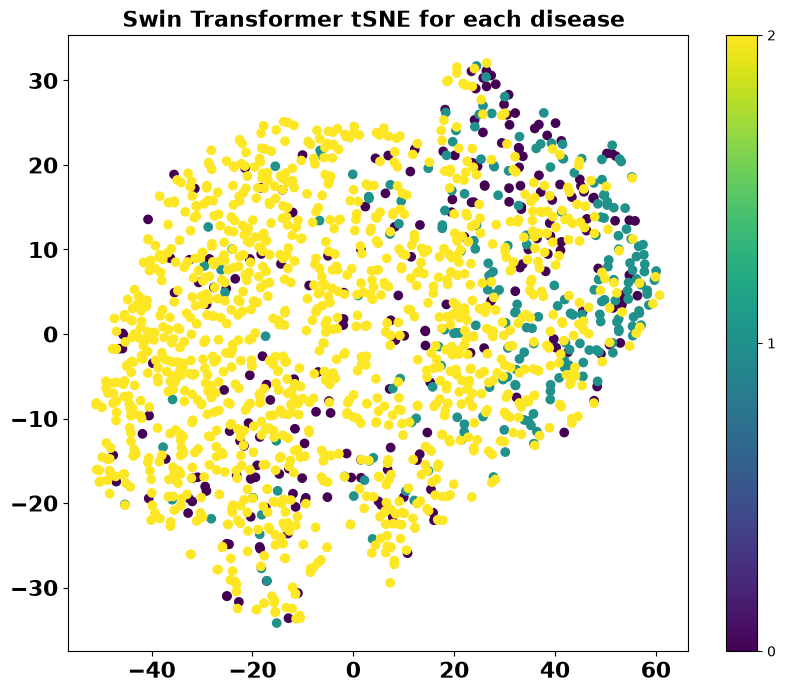

In [ ]:
swinscore.eval()
swinn = swinscore.head                  
swinscore.head = torch.nn.Identity()

out = np.empty((0, 768))   
label = []               

for batch in tqdm(testt, desc='Extracting Test Set Features'):
    images = batch[0].to(device)
    diseases = batch[1]       
    with torch.no_grad():
        output = swinscore(images)     
        
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + diseases.tolist() 
swinscore.head = swinn                  

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure(figsize=(10, 8))
tx = tsnevis[:, 0]
ty = tsnevis[:, 1]

scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[0, 1, 2])
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.title("Swin Transformer tSNE for each disease ", fontsize=16, fontweight='bold') 
plt.show()

In [ ]:
swinscore.eval()
swinn = swinscore.head                  
swinscore.head = torch.nn.Identity()

out = np.empty((0, 768))     
label = []

for batch in fitz1data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)     
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [1] * len(images)

for batch in fitz2data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)   
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [2] * len(images)

for batch in fitz3data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)    
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [3] * len(images)

for batch in fitz4data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)   
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [4] * len(images)

for batch in fitz5data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)  
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [5] * len(images)

for batch in fitz6data:
    images = batch[0].to(device)
    with torch.no_grad():
        output = swinscore(images)  
    out = np.concatenate((out, output.cpu().numpy()))
    label = label + [6] * len(images)

swinscore.head = swinn                 

feat = out
tsnevis = TSNE(n_components=2, random_state=42).fit_transform(feat)

plt.figure(figsize=(10, 8))
tx = tsnevis[:, 0]
ty = tsnevis[:, 1]
scatter = plt.scatter(tx, ty, c=label) 
plt.colorbar(scatter, ticks=[1, 2, 3, 4, 5, 6])
plt.title("Swin transformer tSNE") 
plt.show()

In [ ]:

print("Evaluating Fitzpatrick 1 for Swin Transformer")
evaluatefitz(swinscore, testt, device)

Evaluating Fitzpatrick 1 for Swin Transformer
The  accuracy for the dataset is : 0.7309612983770287
The precision for the dataset is [0.        0.        0.7309613]
The AUC score for the dataset is 0.531356167597838
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7574154562675036
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[   0    0  215]
 [   0    0  216]
 [   0    0 1171]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 1 for Swin Transformer")
evaluatefitz(swinscore, fitz1data, device)

Evaluating Fitzpatrick 1 for Swin Transformer
The  accuracy for the dataset is : 0.6949152542372882
The precision for the dataset is [0.         0.         0.69491525]
The AUC score for the dataset is 0.5354760836823368
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7961603403091431
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  44]
 [  0   0  46]
 [  0   0 205]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 2 for Swin Transformer")
evaluatefitz(swinscore, fitz2data, device)

Evaluating Fitzpatrick 2 for Swin Transformer
The  accuracy for the dataset is : 0.7068607068607069
The precision for the dataset is [0.         0.         0.70686071]
The AUC score for the dataset is 0.5269626598870734
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7833463102579117
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  67]
 [  0   0  74]
 [  0   0 340]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 3 for Swin Transformer")
evaluatefitz(swinscore, fitz3data, device)

Evaluating Fitzpatrick 3 for Swin Transformer
The  accuracy for the dataset is : 0.7168674698795181
The precision for the dataset is [0.         0.         0.71686747]
The AUC score for the dataset is 0.4838899583892308
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.7375752478837967
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  48]
 [  0   0  46]
 [  0   0 238]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 4 for Swin Transformer")
evaluatefitz(swinscore, fitz4data, device)

Evaluating Fitzpatrick 4 for Swin Transformer
The  accuracy for the dataset is : 0.762589928057554
The precision for the dataset is [0.         0.         0.76258993]
The AUC score for the dataset is 0.5003300272967041
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.675876122713089
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  36]
 [  0   0  30]
 [  0   0 212]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print  ("Evaluating Fitzpatrick 5 for Swin Transformer")
evaluatefitz(swinscore, fitz5data, device)

Evaluating Fitzpatrick 5 for Swin Transformer
The  accuracy for the dataset is : 0.803921568627451
The precision for the dataset is [0.         0.         0.80392157]
The AUC score for the dataset is 0.5865423572025159
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.5966185530026754
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[  0   0  16]
 [  0   0  14]
 [  0   0 123]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Evaluating Fitzpatrick 6 for Swin Transformer")
evaluatefitz(swinscore, fitz6data, device)

Evaluating Fitzpatrick 6 for Swin Transformer
The  accuracy for the dataset is : 0.8412698412698413
The precision for the dataset is [0.         0.         0.84126984]
The AUC score for the dataset is 0.6130288233464306
The recall for the dataset is  [0. 0. 1.]
The Loss: for the dataaset is 0.6095500588417053
The False Negative Rate for the dataset is [1. 1. 0.]
The confusion matrix for the dataset is:[[ 0  0  4]
 [ 0  0  6]
 [ 0  0 53]]
The balanced accuracy for the dataset is: 0.3333333333333333


c:\Users\akhil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


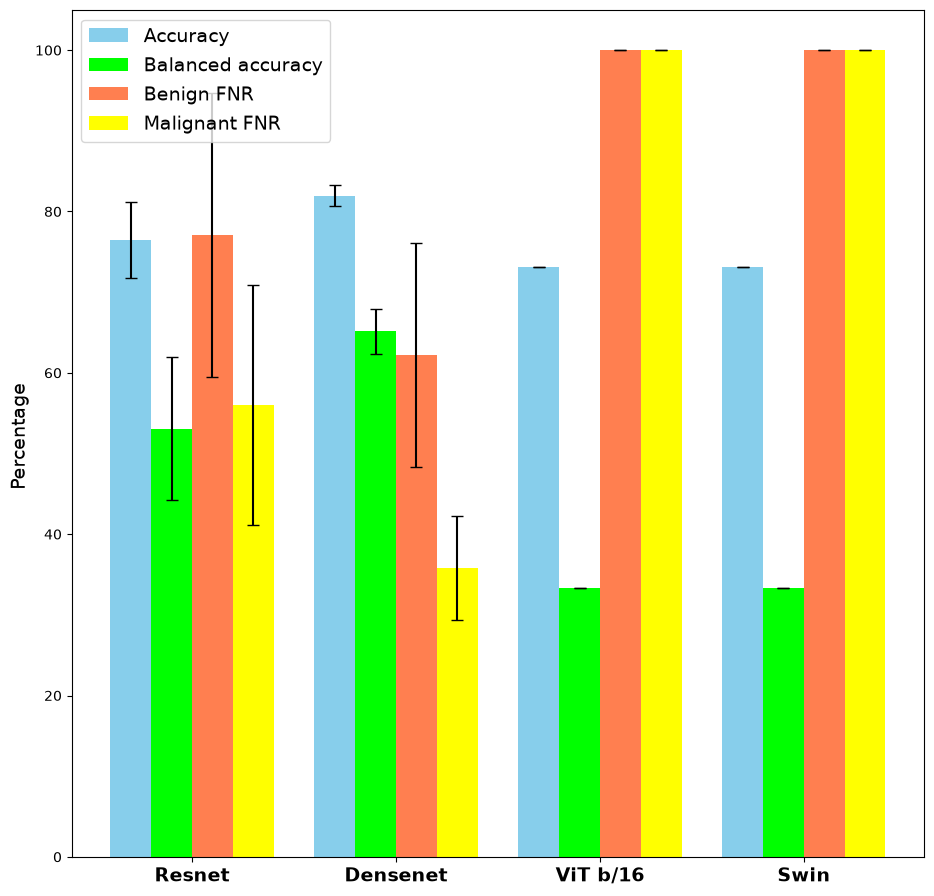

In [153]:
import matplotlib.pyplot as plt


models = ["Resnet", "Densenet", "ViT b/16", "Swin"]
x = np.arange(4)
modelaccuracies = [76.43, 81.98, 73.10, 73.10]
modelbalancedaccur = [53.05, 65.13, 33.33, 33.33]
benignfnr = [77.05, 62.17, 100.0, 100.0]  # converted FNR to percentage
malignantfnr = [56.02, 35.80, 100.0, 100.0]
sdaccuracy = [4.72, 1.35, 0.00, 0.00]
sdbalancedacc = [8.86, 2.78, 0.00, 0.00]
sdbenign = [17.60, 13.88, 0.00, 0.00]
sdmalignant = [14.85, 6.49, 0.00, 0.00]

width = 0.2
plt.figure(figsize=(11, 11))
# Offset positions so they are centered over each model name
plt.bar(x - 1.5 * width, modelaccuracies, width, color="skyblue", label="Accuracy")
plt.bar(x - 0.5 * width, modelbalancedaccur, width, color="lime", label="Balanced accuracy")
plt.bar(x + 0.5 * width, benignfnr, width, color="coral", label="Benign FNR")
plt.bar(x + 1.5 * width, malignantfnr, width, color="yellow", label="Malignant FNR")
accdif = [sdaccuracy[0], sdaccuracy[1], sdaccuracy[2], sdaccuracy[3]]
balancedaccdif = [sdbalancedacc[0], sdbalancedacc[1], sdbalancedacc[2], sdbalancedacc[3]]
benignfnrdiff = [sdbenign[0], sdbenign[1], sdbenign[2], sdbenign[3]]
malignantfnrdiff = [sdmalignant[0], sdmalignant[1], sdmalignant[2], sdmalignant[3]]

plt.errorbar(x - 1.5 * width, modelaccuracies, yerr=accdif, fmt="none", color="black", capsize=4)
plt.errorbar(x - 0.5 * width, modelbalancedaccur, yerr=balancedaccdif, fmt="none", color="black", capsize=4)
plt.errorbar(x + 0.5 * width, benignfnr, yerr=benignfnrdiff, fmt="none", color="black", capsize=4)
plt.errorbar(x + 1.5 * width, malignantfnr, yerr=malignantfnrdiff, fmt="none", color="black", capsize=4)

plt.xticks(x, models,fontsize=14,fontweight='bold')
plt.ylabel("Percentage ",fontsize=14)
plt.legend(fontsize=14)

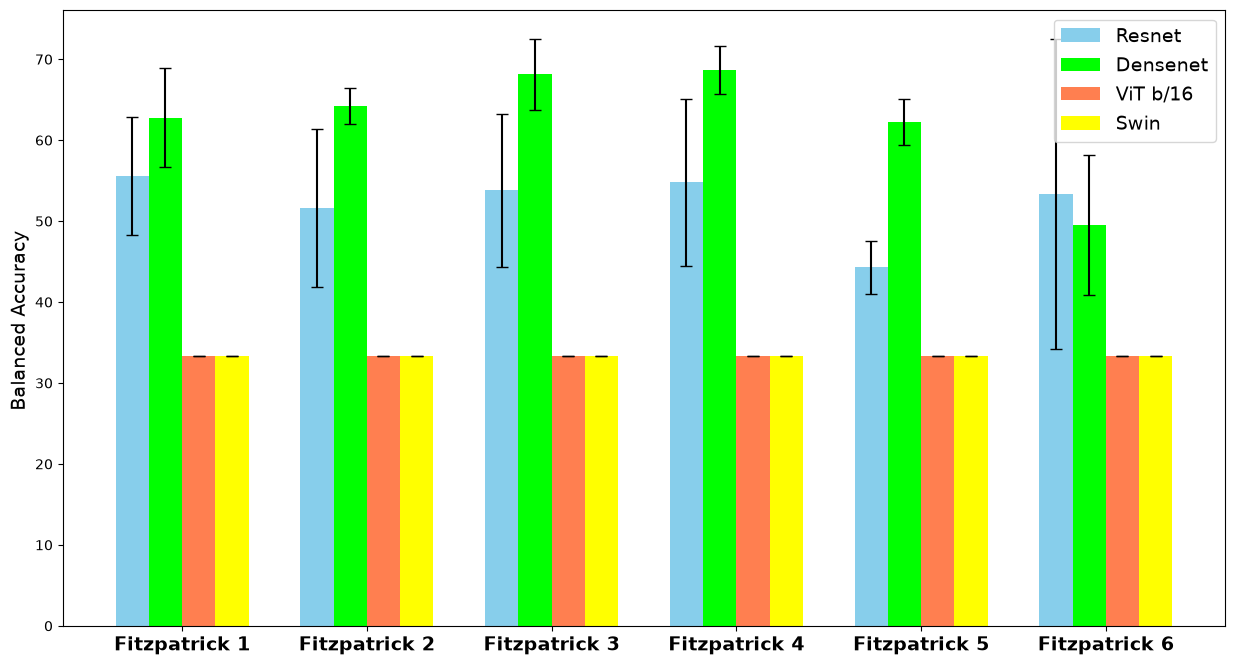

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fitzscore = ["Fitzpatrick 1", "Fitzpatrick 2", "Fitzpatrick 3", "Fitzpatrick 4", "Fitzpatrick 5", "Fitzpatrick 6"]
x = np.arange(len(fitzscore))
width = 0.18

resnetscore = [55.62, 51.63, 53.81, 54.82, 44.28, 53.37]
densenetscore = [62.78, 64.26, 68.13, 68.67, 62.27, 49.55]
vitscore = [33.33, 33.33, 33.33, 33.33, 33.33, 33.33]
swinscore = [33.33, 33.33, 33.33, 33.33, 33.33, 33.33]

sdresnet = [7.29, 9.79, 9.48, 10.32, 3.28, 19.11]
sddensenet = [6.13, 2.20, 4.35, 3.00, 2.82, 8.65]
sdvit = [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]
sdswin = [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]

respos = x - 1.5 * width
densepos = x - 0.5 * width
vitpos = x + 0.5 * width
swinpos = x + 1.5 * width

plt.figure(figsize=(15, 8))

plt.bar(respos, resnetscore, width, color="skyblue", label="Resnet")
plt.bar(densepos, densenetscore, width, color="lime", label="Densenet")
plt.bar(vitpos, vitscore, width, color="coral", label="ViT b/16")
plt.bar(swinpos, swinscore, width, color="yellow", label="Swin")

plt.errorbar(respos, resnetscore, yerr=sdresnet, fmt="none", color="black", capsize=4)
plt.errorbar(densepos, densenetscore, yerr=sddensenet, fmt="none", color="black", capsize=4)
plt.errorbar(vitpos, vitscore, yerr=sdvit, fmt="none", color="black", capsize=4)
plt.errorbar(swinpos, swinscore, yerr=sdswin, fmt="none", color="black", capsize=4)

plt.xticks(x, fitzscore, fontsize=14, fontweight="bold")
plt.ylabel("Balanced Accuracy ", fontsize=14)
plt.legend(fontsize=14)

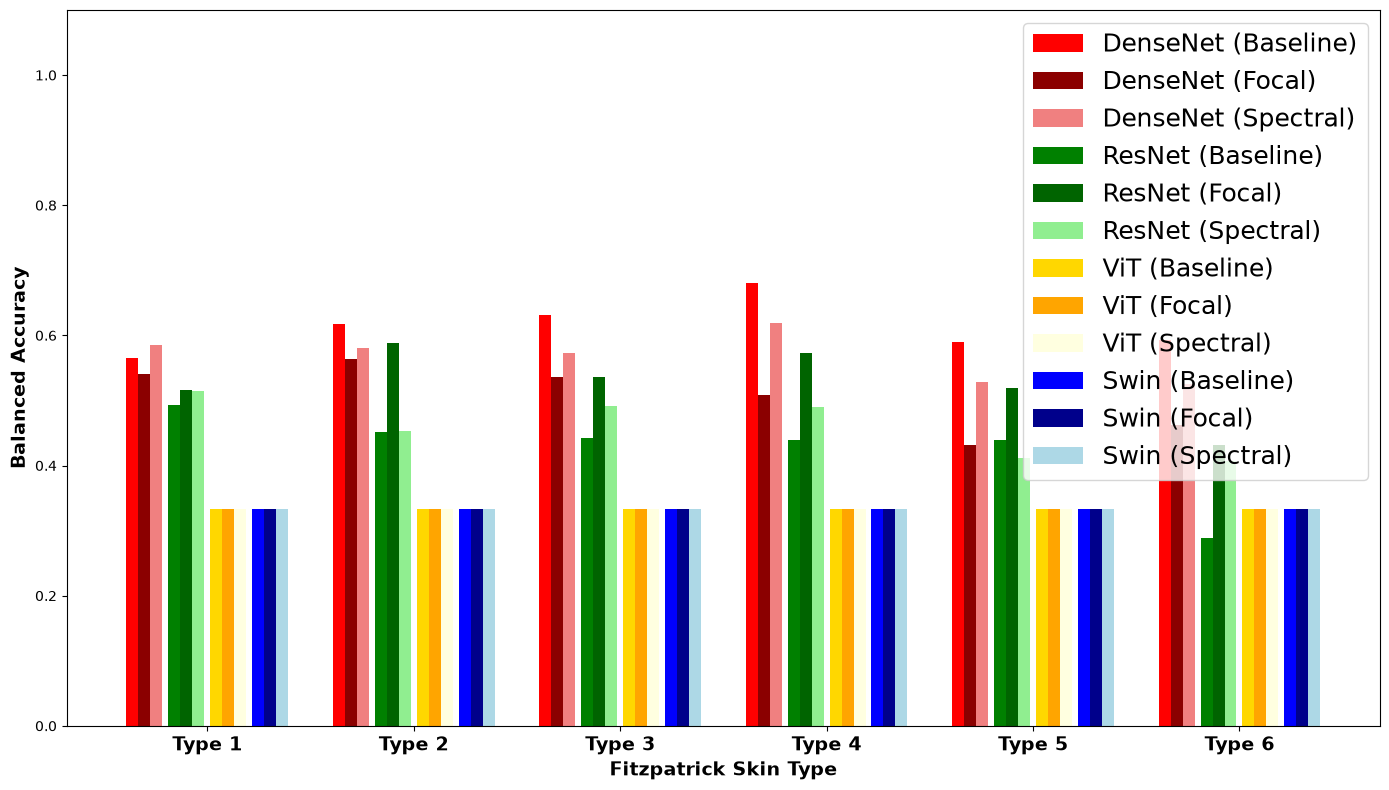

In [ ]:
##balanced accuracy
import matplotlib.pyplot as plt
import numpy as np

fitzscore = ['Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6']
x = np.arange(len(fitzscore))

baselinedensenet = [0.5658, 0.6174, 0.6318, 0.6812, 0.5891, 0.5922]
focaldensenent = [0.5410, 0.5637, 0.5355, 0.5083, 0.4312, 0.4623]
spectraldensenet = [0.5857, 0.5804, 0.5735, 0.6184, 0.5282, 0.5258]

baselineresnet = [0.4936, 0.4520, 0.4430, 0.4393, 0.4385, 0.2893]
focalresnet = [0.5153, 0.5880, 0.5353, 0.5724, 0.5199, 0.4308]
spectralresnet = [0.5145, 0.4538, 0.4915, 0.4904, 0.4123, 0.4067]


baselinevit = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]
focalvit = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]
spectralvit = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]

baselineswin = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]
focalswin    = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]
spectralswin     = [0.3333, 0.3333, 0.3333, 0.3333, 0.3333, 0.3333]

width = 0.058

plt.figure(figsize=(14, 8))

plt.bar(x - 5.5*width, baselinedensenet, width, label='DenseNet (Baseline)', color='red')
plt.bar(x - 4.5*width, focaldensenent, width, label='DenseNet (Focal)', color='darkred')
plt.bar(x - 3.5*width, spectraldensenet, width, label='DenseNet (Spectral)', color='lightcoral')

plt.bar(x - 2.0*width, baselineresnet, width, label='ResNet (Baseline)', color='green')
plt.bar(x - 1.0*width, focalresnet, width, label='ResNet (Focal)', color='darkgreen')
plt.bar(x - 0.0*width, spectralresnet, width, label='ResNet (Spectral)', color='lightgreen')

plt.bar(x + 1.5*width, baselinevit, width, label='ViT (Baseline)', color='gold')
plt.bar(x + 2.5*width, focalvit, width, label='ViT (Focal)', color='orange')
plt.bar(x + 3.5*width, spectralvit, width, label='ViT (Spectral)', color='lightyellow')

plt.bar(x + 5.0*width, baselineswin, width, label='Swin (Baseline)', color='blue')
plt.bar(x + 6.0*width, focalswin, width, label='Swin (Focal)', color='darkblue')
plt.bar(x + 7.0*width, spectralswin, width, label='Swin (Spectral)', color='lightblue')

plt.xlabel('Fitzpatrick Skin Type', fontsize=14, fontweight='bold')
plt.ylabel('Balanced Accuracy', fontsize=14, fontweight='bold')

plt.xticks(x + 0.75*width, fitzscore, fontsize=14, fontweight='bold')
plt.ylim(0.0, 1.1)

plt.legend(loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()

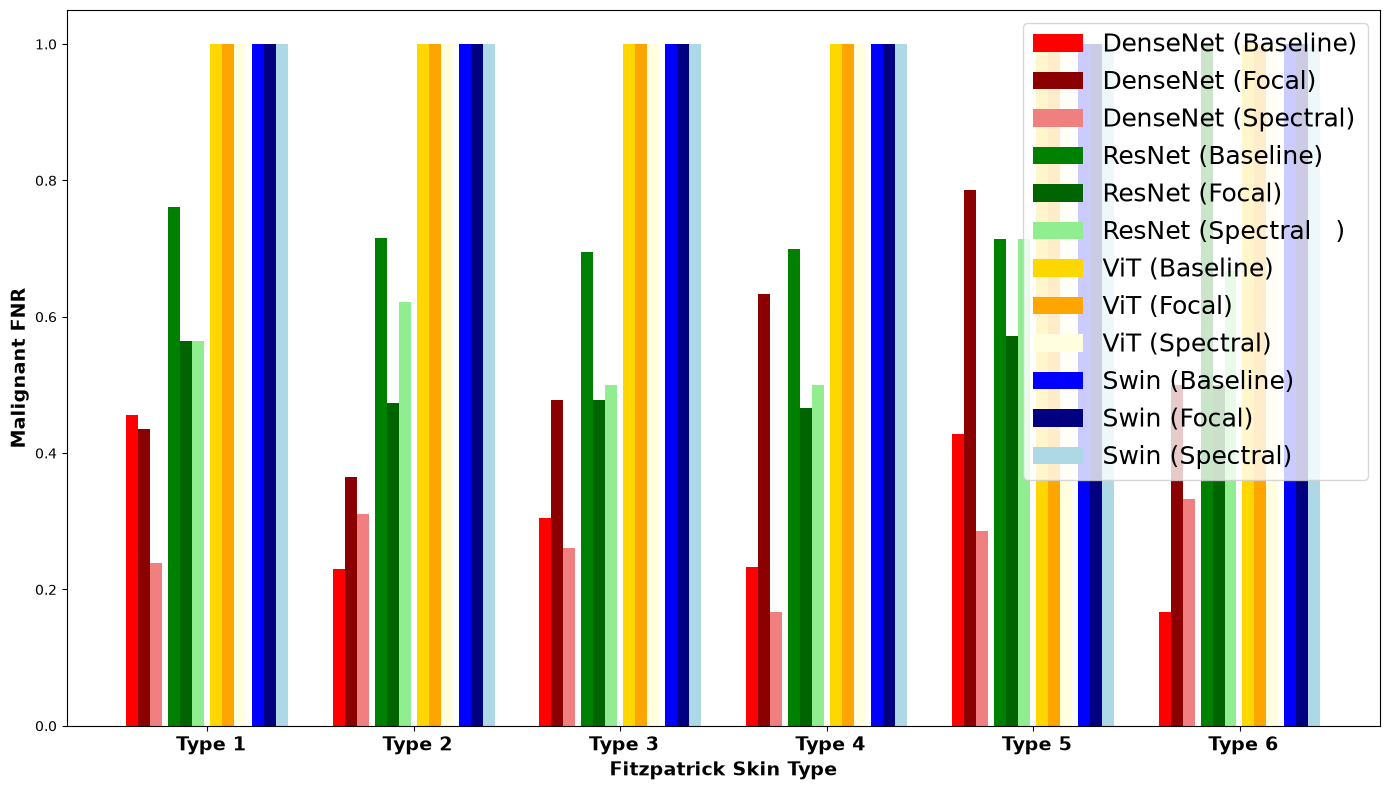

In [ ]:
##malignant FNR
import matplotlib.pyplot as plt
import numpy as np

fitzscore = [' Type 1', ' Type 2', ' Type 3', ' Type 4', ' Type 5', ' Type 6']
x = np.arange(len(fitzscore))


baselinedensenet = [0.4565, 0.2297, 0.3043, 0.2333, 0.4286, 0.1667]
focaldensenent = [0.4348, 0.3649, 0.4783, 0.6333, 0.7857, 0.5000]
spectraldensenet = [0.2391, 0.3108, 0.2609, 0.1667, 0.2857, 0.3333]

baselineresnet = [0.7609, 0.7162, 0.6957, 0.7000, 0.7143, 1.0000]
focalresnet = [0.5652, 0.4730, 0.4783, 0.4667, 0.5714, 0.5000]
spectralresnet = [0.5652, 0.6216, 0.5000, 0.5000, 0.7143, 0.6667]


baselinevit = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
focalvit = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
spectralvit = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]

baselineswin     = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
focalswin        = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
spectralswin         = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]


width = 0.058


plt.figure(figsize=(14, 8))

plt.bar(x - 5.5*width, baselinedensenet, width, label='DenseNet (Baseline)', color='red')
plt.bar(x - 4.5*width, focaldensenent, width, label='DenseNet (Focal)', color='darkred')
plt.bar(x - 3.5*width, spectraldensenet, width, label='DenseNet (Spectral)', color='lightcoral')

plt.bar(x - 2.0*width, baselineresnet, width, label='ResNet (Baseline)', color='green')
plt.bar(x - 1.0*width, focalresnet, width, label='ResNet (Focal)', color='darkgreen')
plt.bar(x - 0.0*width, spectralresnet, width, label='ResNet (Spectral   )', color='lightgreen')

plt.bar(x + 1.5*width, baselinevit, width, label='ViT (Baseline)', color='gold')
plt.bar(x + 2.5*width, focalvit, width, label='ViT (Focal)', color='orange')
plt.bar(x + 3.5*width, spectralvit, width, label='ViT (Spectral)', color='lightyellow')

plt.bar(x + 5.0*width, baselineswin, width, label='Swin (Baseline)', color='blue')
plt.bar(x + 6.0*width, focalswin, width, label='Swin (Focal)', color='navy')
plt.bar(x + 7.0*width, spectralswin, width, label='Swin (Spectral)', color='lightblue')

plt.xlabel('Fitzpatrick Skin Type', fontsize=14,fontweight='bold')
plt.ylabel('Malignant FNR', fontsize=14,fontweight='bold')

plt.xticks(x + 0.77*width, fitzscore, fontsize=14,fontweight='bold')

plt.legend( loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()

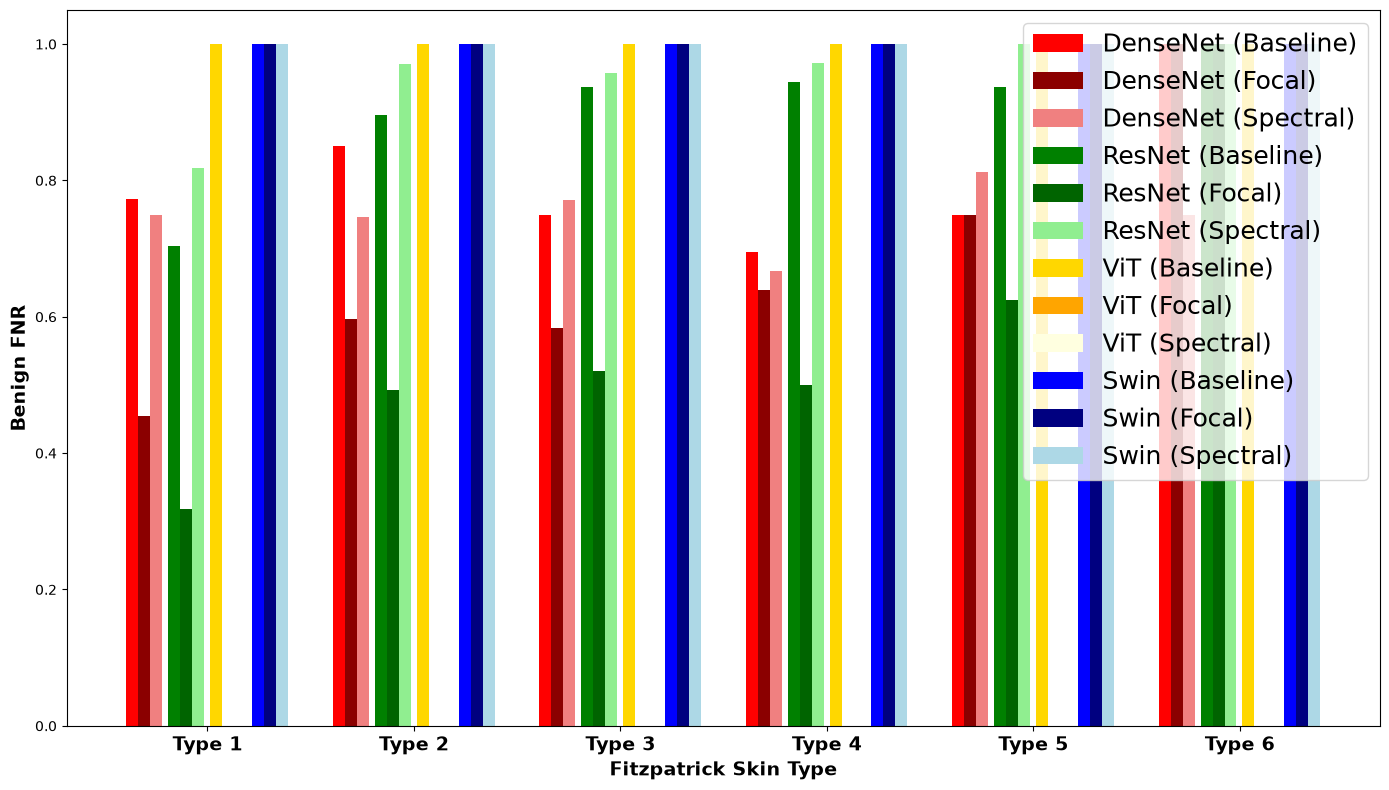

In [163]:
##benign FNR
import matplotlib.pyplot as plt
import numpy as np

fitzscore = ['Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6']
x = np.arange(len(fitzscore))

baselinedensenet = [0.7727, 0.8507, 0.7500, 0.6944, 0.7500, 1.0000]
focaldensenent = [0.4545, 0.5970, 0.5833, 0.6389, 0.7500, 1.0000]
spectraldensenet = [0.7500, 0.7463, 0.7708, 0.6667, 0.8125, 0.7500]

baselineresnet = [0.7045, 0.8955, 0.9375, 0.9444, 0.9375, 1.0000]
focalresnet = [0.3182, 0.4925, 0.5208, 0.5000, 0.6250, 1.0000]
spectralresnet = [0.8182, 0.9701, 0.9583, 0.9722, 1.0000, 1.0000]

baselinevit      = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
focalvit         = [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
spectralvit          = [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]

baselineswin     = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
focalswin        = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
spectralswin         = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]

width = 0.058

plt.figure(figsize=(14, 8))

plt.bar(x - 5.5*width, baselinedensenet, width, label='DenseNet (Baseline)', color='red')
plt.bar(x - 4.5*width, focaldensenent, width, label='DenseNet (Focal)', color='darkred')
plt.bar(x - 3.5*width, spectraldensenet, width, label='DenseNet (Spectral)', color='lightcoral')


plt.bar(x - 2.0*width, baselineresnet, width, label='ResNet (Baseline)', color='green')
plt.bar(x - 1.0*width, focalresnet, width, label='ResNet (Focal)', color='darkgreen')
plt.bar(x - 0.0*width, spectralresnet, width, label='ResNet (Spectral)', color='lightgreen')

plt.bar(x + 1.5*width, baselinevit, width, label='ViT (Baseline)', color='gold')
plt.bar(x + 2.5*width, focalvit, width, label='ViT (Focal)', color='orange')
plt.bar(x + 3.5*width, spectralvit, width, label='ViT (Spectral)', color='lightyellow')

plt.bar(x + 5.0*width, baselineswin, width, label='Swin (Baseline)', color='blue')
plt.bar(x + 6.0*width, focalswin, width, label='Swin (Focal)', color='navy')
plt.bar(x + 7.0*width, spectralswin, width, label='Swin (Spectral)', color='lightblue')


plt.xlabel('Fitzpatrick Skin Type', fontsize=14, fontweight='bold')
plt.ylabel('Benign FNR', fontsize=14, fontweight='bold')

plt.xticks(x + 0.77*width, fitzscore, fontsize=14, fontweight='bold')

plt.legend( loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()